# Healthcare Test Results Prediction

### Advanced Data Analysis — NTI Batch 9

**Instructor:** Eng. Huda Hemdan

This project aims to build a classification system that predicts a patient's initial Test Result (Normal / Abnormal / Inconclusive) at admission time using available patient and admission data.

# **Introduction**

Healthcare services and hospital management systems have transformed the way medical facilities operate by handling massive volumes of patient admissions, clinical treatments, and financial transactions. While this operational scale enhances patient care and broadens network reach, it also introduces significant operational and financial risks for healthcare providers and insurance companies. Identifying patterns in length of stay, optimizing resource allocation, and controlling high-cost anomalies have become critical challenges in the modern health-tech and management sector.

This project leverages data analytics and machine learning to explore patient admission dynamics, financial billing patterns, and clinical risk factors across a extensive healthcare dataset of 54,966 records. Through exploratory data analysis and predictive modeling, the project aims to uncover actionable insights and support smarter managerial decisions that balance high-quality patient outcomes with sustainable financial management.

# **Business Problem**

Healthcare providers face increasing challenges in managing operational efficiency and financial costs while maintaining high-quality patient care. Uncontrolled lengths of stay and unoptimized admission protocols can lead to significant financial losses and bed capacity bottlenecks, while overly restrictive operational policies may compromise emergency responsiveness and patient satisfaction.

The organization needs a data-driven approach to identify cost risk patterns, understand admission dynamics, and predict clinical test outcomes before making strategic operational decisions.

# **Project Objectives**

Healthcare organizations generate large amounts of patient and hospital admission data.
Analyzing this data can help identify patterns in patient characteristics and test outcomes.

In this project, we will analyze healthcare admission data and build a classification model to predict the patient's initial Test Result at admission time.

The target variable has three classes:

- Normal
- Abnormal
- Inconclusive

# **Dataset Description**

The Healthcare & Hospital Management Dataset contains patient, clinical, operational, and billing-related information collected from hospital admissions. The dataset is designed to support healthcare risk analysis, resource optimization, and predictive modeling within the health-tech industry.

Key Information Included:

Patient demographic attributes such as age, gender, and blood type.

Operational indicators including admission date, discharge date, and length of stay.

Clinical indicators such as medical condition, prescribed medication, and test results.

Financial attributes including billing amount and insurance provider.

Behavioral and transactional characteristics that influence resource utilization and billing patterns.

Test Results: Normal, Abnormal, Inconclusive (used as target outcomes for clinical predictive modeling).

By combining business intelligence techniques with predictive analytics, this dataset provides a comprehensive foundation for understanding operational efficiency and optimizing healthcare management processes.


🔗[Dataset](https://www.kaggle.com/datasets/prasad22/healthcare-dataset)

## Business Questions

1. Is there a relationship between Medical Condition and Test Results?
2. Does Admission Type (Urgent/Emergency/Elective) affect the test outcome?
3. Is Age a significant factor in test outcome?
4. Do Insurance Provider or Hospital show any distributional bias in outcomes?
5. Which classification model best predicts Test Results?

# **Import Libraries**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data loading**

In [75]:
df = pd.read_csv("/content/healthcare_dataset.csv")


# **Understand The Data**

In [76]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [18]:
df.shape

(55500, 15)

In [19]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [20]:
df.dtypes

,0
Name,object
Age,int64
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,object
Doctor,object
Hospital,object
Insurance Provider,object
Billing Amount,float64


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [22]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [23]:
df.describe(include="object")

,Name,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500
unique,49992,2,8,6,1827,40341,39876,5,3,1856,5,3
top,DAvId muNoZ,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,Elective,2020-03-15,Lipitor,Abnormal
freq,3,27774,6969,9308,50,27,44,11249,18655,53,11140,18627


# **Profile report**

In [77]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00


In [78]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Healthcare Dataset Profiling Report")
profile.to_notebook_iframe()

/tmp/ipykernel_1788/4277340793.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:04<00:00,  3.37it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# **Missing Value**

In [24]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


# **Duplicates**

In [25]:
df[df.duplicated(keep=False)].head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
64,Nancy glOVeR,58,Male,A-,Hypertension,2020-05-08,Jennifer Larson,"Khan, and Rodriguez Fischer",Medicare,19183.168885,378,Emergency,2020-06-01,Aspirin,Abnormal
107,DAVid higgInS,49,Female,B-,Arthritis,2021-03-05,Erin Henderson MD,"Evans and Hall Schneider,",Medicare,24948.477824,361,Emergency,2021-03-20,Penicillin,Abnormal
148,RoBErt hIGGInS,42,Male,AB-,Asthma,2021-05-06,Scott Davis,"and Ford Lee, Rodriguez",Medicare,13355.782085,451,Elective,2021-05-29,Ibuprofen,Inconclusive
154,kevIn HiCKs,66,Male,AB+,Arthritis,2021-06-23,Kelly Murphy,Robinson Inc,Medicare,1897.891727,196,Elective,2021-07-09,Ibuprofen,Abnormal
159,miCHAeL TayloR,29,Male,O-,Asthma,2020-02-27,Erica Mccormick,Donaldson-Frey,Medicare,41939.119937,453,Elective,2020-03-26,Ibuprofen,Normal


In [26]:
df.duplicated().sum()

np.int64(534)

In [80]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# **Data Formatting & Conversion**

In [81]:
df["Name"] = df["Name"].astype("string").str.strip().str.title()
df['Hospital'] = df['Hospital'].astype("string").str.strip().str.title()

In [83]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

df[["Date of Admission", "Discharge Date"]].dtypes

,0
Date of Admission,datetime64[ns]
Discharge Date,datetime64[ns]


In [84]:
df["Length of Stay"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

In [85]:
df["Length of Stay"].describe()

,Length of Stay
count,54966.000000
mean,15.499290
std,8.661471
min,1.000000
25%,8.000000
50%,15.000000
75%,23.000000
max,30.000000


In [86]:
invalid_dates = df[
    df["Discharge Date"] < df["Date of Admission"]
]

invalid_dates.shape

(0, 16)

In [87]:
df["Billing Amount"].describe()

,Billing Amount
count,54966.000000
mean,25544.306284
std,14208.409711
min,-2008.492140
25%,13243.718641
50%,25542.749145
75%,37819.858159
max,52764.276736


In [88]:
(df["Billing Amount"] < 0).sum()

np.int64(106)

In [38]:
df['Billing Amount'] = df['Billing Amount'].mask(df['Billing Amount'] < 0)
df['Billing Amount'] = df['Billing Amount'].fillna(
    df.groupby('Medical Condition')['Billing Amount'].transform('mean')
)

df['Billing Amount'].isna().sum()

np.int64(0)

In [39]:
(df["Billing Amount"] < 0).sum()


np.int64(0)

In [72]:
total_billing = df['Billing Amount'].sum()
print(total_billing)


1406834916.8744178


In [89]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1
Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR
age_outliers = df[
    (df["Age"] < Lower_Bound) |
    (df["Age"] > Upper_Bound)
]
outliers_age = pd.DataFrame({
    'Column': ['Age'],
    'Lower Bound': [Lower_Bound],
    'Upper Bound': [Upper_Bound],
    'Outliers': [age_outliers.shape[0]]
})

outliers_age

,Column,Lower Bound,Upper Bound,Outliers
0,Age,-14.5,117.5,0


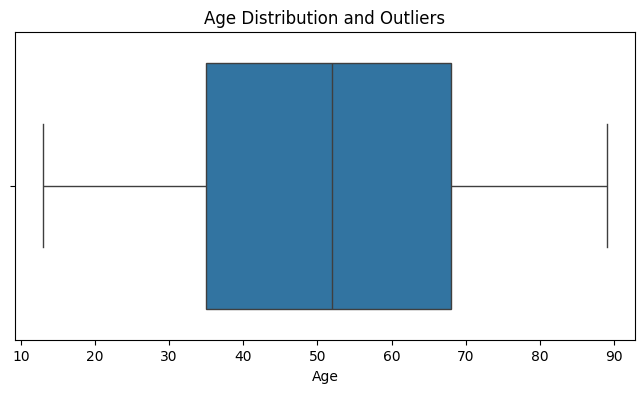

In [90]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Age"])

plt.title("Age Distribution and Outliers")
plt.xlabel("Age")

plt.show()

# **Exploratory Data Analysis (EDA)**

In [43]:
df["Test Results"].value_counts()

,count
Test Results,
Abnormal,18437
Normal,18331
Inconclusive,18198


In [44]:
target_percentage = (
    df["Test Results"]
    .value_counts(normalize=True) * 100
).round(2)

target_percentage

,proportion
Test Results,
Abnormal,33.54
Normal,33.35
Inconclusive,33.11


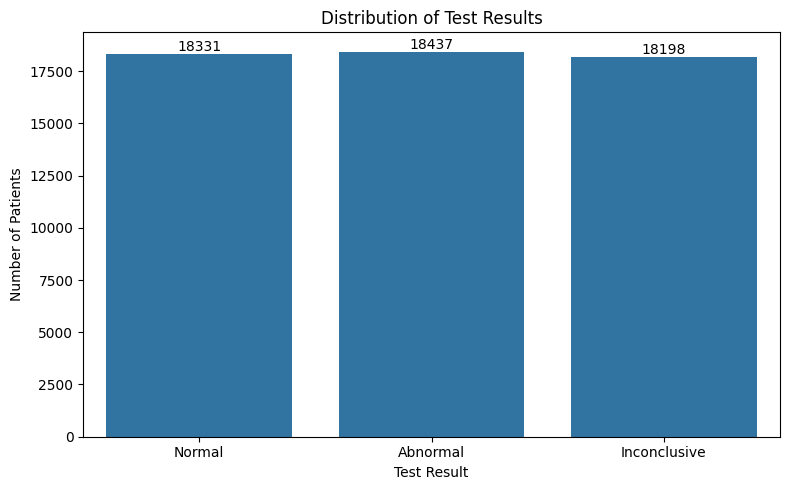

In [45]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Test Results",
    order=["Normal", "Abnormal", "Inconclusive"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Test Results")
plt.xlabel("Test Result")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

## Business Question 1

### Is there a relationship between Medical Condition and Test Results?

In [46]:
pd.crosstab(
    df["Medical Condition"],
    df["Test Results"]
)

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,3156,3062,3000
Asthma,2980,2999,3116
Cancer,3089,3033,3018
Diabetes,3131,3024,3061
Hypertension,2977,3068,3106
Obesity,3104,3012,3030


In [47]:
condition_test_percentage = pd.crosstab(
    df["Medical Condition"],
    df["Test Results"],
    normalize="index"
) * 100

condition_test_percentage.round(2)

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,34.24,33.22,32.55
Asthma,32.77,32.97,34.26
Cancer,33.80,33.18,33.02
Diabetes,33.97,32.81,33.21
Hypertension,32.53,33.53,33.94
Obesity,33.94,32.93,33.13


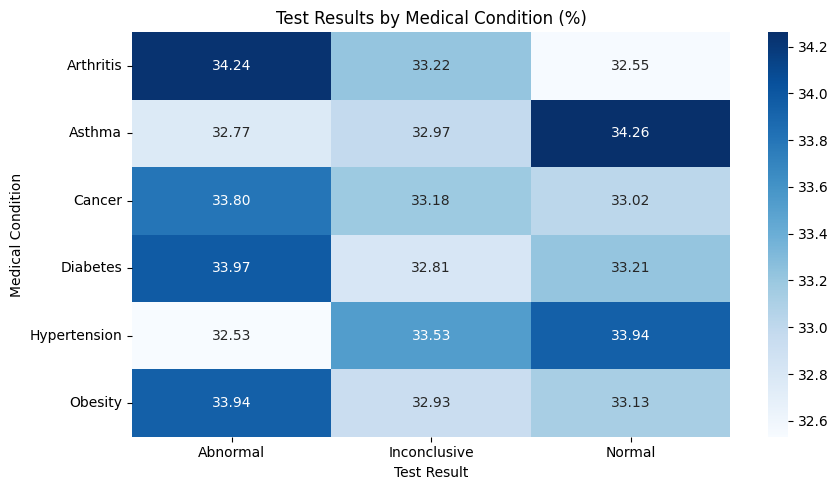

In [48]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    condition_test_percentage,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Test Results by Medical Condition (%)")
plt.xlabel("Test Result")
plt.ylabel("Medical Condition")

plt.tight_layout()
plt.show()

## Business Question 2

### Does Admission Type (Urgent/Emergency/Elective) affect the test outcome?

In [49]:
pd.crosstab(
    df["Admission Type"],
    df["Test Results"]
)

Test Results,Abnormal,Inconclusive,Normal
Admission Type,,,
Elective,6232,6054,6187
Emergency,6038,6020,6044
Urgent,6167,6124,6100


In [50]:
admission_test_percentage = pd.crosstab(
    df["Admission Type"],
    df["Test Results"],
    normalize="index"
) * 100

admission_test_percentage.round(2)

Test Results,Abnormal,Inconclusive,Normal
Admission Type,,,
Elective,33.74,32.77,33.49
Emergency,33.36,33.26,33.39
Urgent,33.53,33.30,33.17


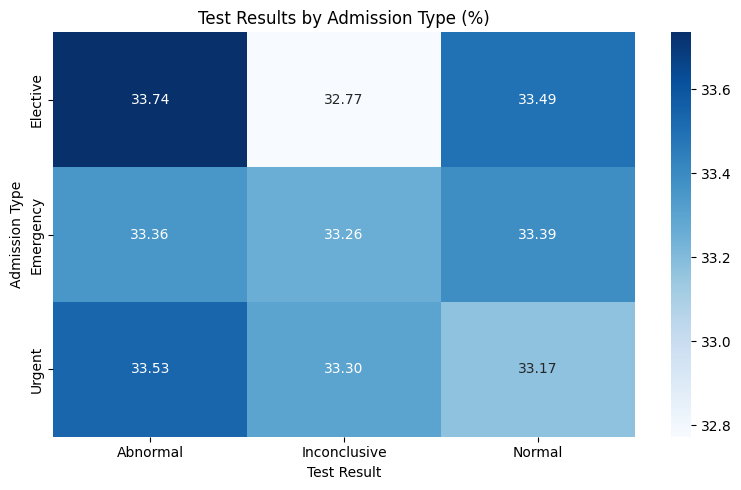

In [51]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    admission_test_percentage,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Test Results by Admission Type (%)")
plt.xlabel("Test Result")
plt.ylabel("Admission Type")

plt.tight_layout()
plt.show()

## Business Question 3

### Is Age a significant factor in test outcome?

In [52]:
df.groupby("Test Results")["Age"].mean().round(2)

,Age
Test Results,
Abnormal,51.64
Inconclusive,51.66
Normal,51.31


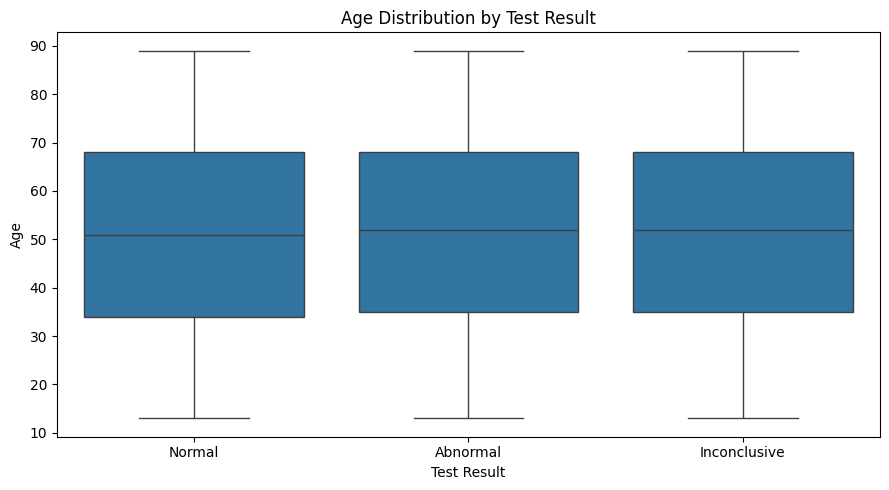

In [53]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Test Results",
    y="Age",
    order=["Normal", "Abnormal", "Inconclusive"]
)

plt.title("Age Distribution by Test Result")
plt.xlabel("Test Result")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

## Business Question 4

### Do Insurance Provider or Hospital show any distributional bias in outcomes?

In [54]:
insurance_test_percentage = pd.crosstab(
    df["Insurance Provider"],
    df["Test Results"],
    normalize="index"
) * 100

insurance_test_percentage.round(2)

Test Results,Abnormal,Inconclusive,Normal
Insurance Provider,,,
Aetna,33.30,33.53,33.16
Blue Cross,32.79,33.81,33.40
Cigna,33.82,33.12,33.06
Medicare,33.90,32.80,33.30
UnitedHealthcare,33.89,32.29,33.82


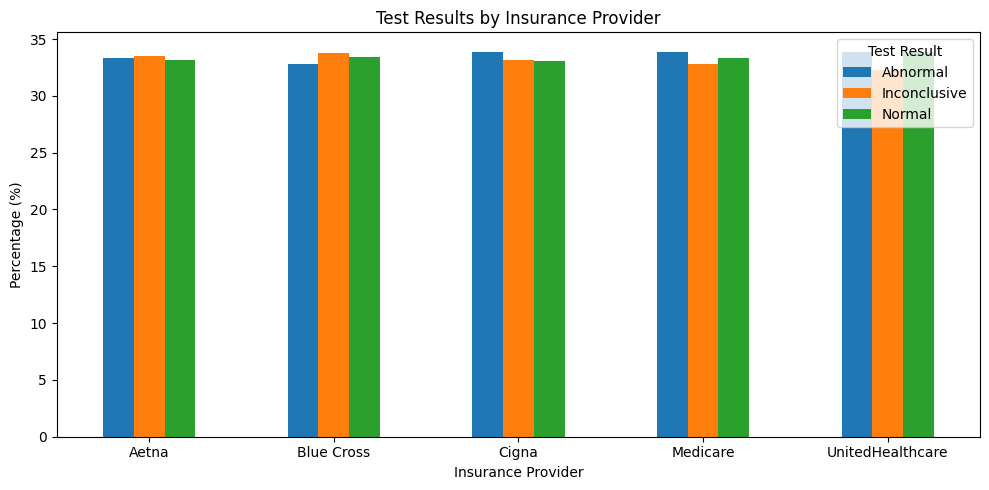

In [55]:
insurance_test_percentage.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Test Results by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Test Result")

plt.tight_layout()
plt.show()

In [56]:
df["Hospital"].value_counts().head(10)

,count
Hospital,
LLC Smith,44
Ltd Smith,39
Johnson PLC,37
Smith Ltd,37
Smith PLC,36
Smith Group,36
Johnson Inc,34
Smith Inc,33
Group Smith,32


In [57]:
top_hospitals = df["Hospital"].value_counts().head(10).index

hospital_test_percentage = pd.crosstab(
    df[df["Hospital"].isin(top_hospitals)]["Hospital"],
    df[df["Hospital"].isin(top_hospitals)]["Test Results"],
    normalize="index"
) * 100

hospital_test_percentage.round(2)

Test Results,Abnormal,Inconclusive,Normal
Hospital,,,
Group Smith,9.38,37.50,53.12
Johnson Inc,35.29,26.47,38.24
Johnson PLC,18.92,56.76,24.32
LLC Smith,38.64,29.55,31.82
Ltd Smith,43.59,25.64,30.77
Smith Group,50.00,19.44,30.56
Smith Inc,9.09,48.48,42.42
Smith LLC,46.88,28.12,25.00
Smith Ltd,21.62,29.73,48.65


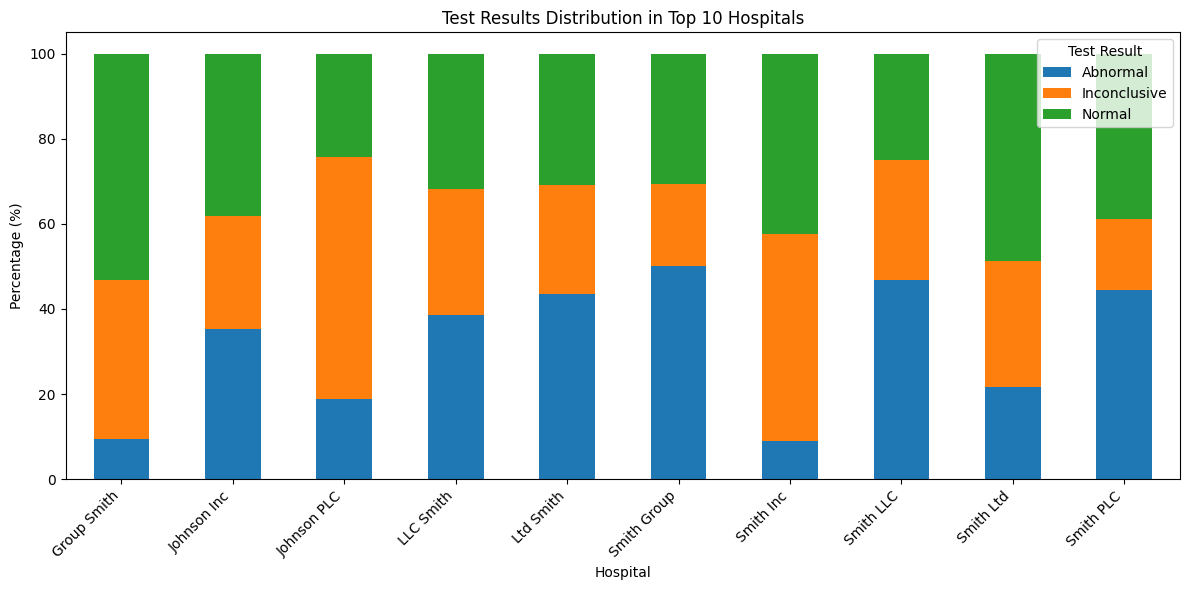

In [58]:
hospital_test_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Test Results Distribution in Top 10 Hospitals")
plt.xlabel("Hospital")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Test Result")

plt.tight_layout()
plt.show()

# **Key Insights**

Patient Profile

*   The patient population covers a broad age range, with the average patient age around 52 years, indicating a substantial representation of middle-aged and older adults.
*   Male and female patients are relatively represented across the dataset, providing a balanced basis for comparing healthcare patterns by gender.
Blood type distribution is spread across the eight blood groups, with no single blood type overwhelmingly dominating the patient population.

Medical Conditions

*   The six medical conditions are distributed across the patient population, allowing comparison of disease patterns across different demographic and clinical groups.
*   The prevalence of medical conditions varies across age groups, highlighting differences in healthcare needs among younger, middle-aged, and older patients.
Comparing medical conditions with gender can reveal differences in patient profiles and condition distribution across male and female patients.
Admission Patterns
*   Hospital admissions are almost evenly distributed across Elective, Urgent, and Emergency admissions, indicating a balanced mix of planned and acute healthcare demand.
*   Certain medical conditions may show a stronger association with emergency admissions, which can help identify conditions requiring greater emergency-care resources.
*   Admission patterns can be further examined over time to identify changes in healthcare demand and periods of unusually high admission volume.

Clinical Outcomes

*   Test results are relatively balanced across Abnormal, Normal, and Inconclusive categories, with no single outcome clearly dominating the dataset.
*   The distribution of test results varies across medical conditions, providing insight into different clinical patterns associated with each condition.
*   Combining medical conditions with admission type and test results provides a more comprehensive view of patient clinical profiles than analyzing each variable independently.

Hospital Stay

*   Length of Stay provides an important measure of hospital resource utilization and can reveal which medical conditions are associated with longer hospital stays.
*   Differences in Length of Stay across medical conditions can help identify areas where hospital resources may be under greater pressure.
*   Combining Length of Stay with Admission Type can provide additional insight into operational differences between Elective, Urgent, and Emergency admissions.

Medication Patterns

*   Medication usage is relatively evenly distributed across the five medications, with no single medication clearly dominating the dataset.
*   Medication patterns vary across medical conditions, allowing identification of commonly associated medications for different patient groups.
*   Medication data should be interpreted as observed treatment patterns rather than evidence of treatment effectiveness.

Time Trends

*   The dataset covers approximately five years of hospital admissions, providing sufficient historical coverage to analyze admission trends over time.
*   Monthly admission patterns can reveal periods of increased or decreased healthcare demand.
*   Tracking medical conditions over time can help identify whether the distribution of specific conditions remains stable or changes across different periods.

Data Quality

*   The dataset contains no missing values across the analyzed fields, providing a strong foundation for further analysis.
*   No invalid or negative age values were identified, and admission dates are valid across the five-year observation period.
*   Approximately 1% of records are identified as duplicates, requiring validation before removal to determine whether they represent true duplicate admissions.






# **Recommendations**

Optimize Hospital Resource Allocation

*   Allocate hospital resources based on admission volumes and the distribution of medical conditions.
*   Increase operational readiness for medical conditions that show higher levels of Emergency or Urgent admissions.
*   Use admission trends to anticipate periods of increased patient demand and improve staffing and resource planning.

Improve Patient Flow Management

*   Monitor Length of Stay across different medical conditions to identify areas associated with longer hospital stays.
*   Analyze admission type alongside Length of Stay to identify potential opportunities for improving patient flow.
*   Use historical admission patterns to support better bed capacity and discharge planning.

Strengthen Clinical Data Monitoring

*   Continuously monitor Test Results across medical conditions to identify notable patterns in Abnormal, Normal, and Inconclusive results.
*   Combine medical condition, age group, admission type, and test results to develop more comprehensive patient profiles.
*   Use data-driven monitoring to identify unusual changes in clinical patterns that may require further investigation.

Improve Medication Monitoring

*   Monitor medication usage across medical conditions to identify the most common treatment patterns in the dataset.
*   Review medication patterns alongside patient characteristics and test results to better understand variations across patient groups.
*   Avoid interpreting medication frequency as treatment effectiveness without additional clinical evidence.

Enhance Hospital Performance Analysis

*   Compare hospitals based on admission volumes, Length of Stay, medical conditions, and admission types.
*   Identify hospitals with unusually high or low operational metrics and investigate the underlying factors.
*   Develop hospital-level KPIs to support continuous performance monitoring and operational decision-making.

Support Data-Driven Decision Making

*   Develop dashboards that track admissions, medical conditions, Length of Stay, admission types, and test-result patterns.
*   Use historical trends to support capacity planning and identify changes in healthcare demand.
*   Regularly review data-quality issues, including duplicate records, to ensure that operational KPIs remain accurate and reliable.

Strengthen Data Quality

*   Investigate the identified duplicate records before removing them to determine whether they represent true duplicate admissions.
*   Introduce a unique Patient ID or Admission ID in future data collection to improve patient and admission tracking.
*   Establish automated data-quality checks for duplicates, missing values, invalid dates, and inconsistent records.


# **Machine Learning(ML)**

In [59]:
features = [
    "Age",
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication"
]

X = df[features]
y = df["Test Results"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']
Target: Test Results


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (43972, 7)
Testing set: (10994, 7)


In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication"
]

numerical_features = [
    "Age"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [62]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", round(baseline_accuracy * 100, 2), "%")

Baseline Accuracy: 33.55 %


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 38.49 %


In [64]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf"))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")

SVM Accuracy: 33.24 %


In [65]:
model_comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "SVM"],
    "Accuracy": [
        baseline_accuracy,
        rf_accuracy,
        svm_accuracy
    ]
})

model_comparison["Accuracy (%)"] = (
    model_comparison["Accuracy"] * 100
).round(2)

model_comparison

,Model,Accuracy,Accuracy (%)
0,Baseline,0.335456,33.55
1,Random Forest,0.384937,38.49
2,SVM,0.332363,33.24


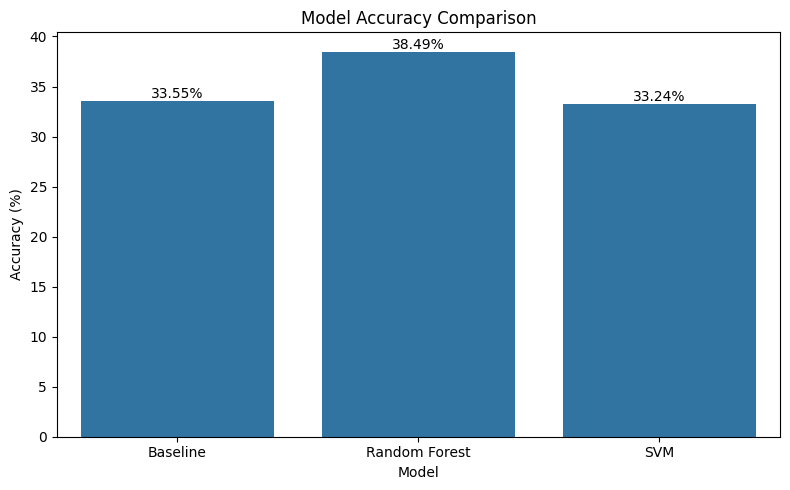

In [66]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy (%)"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

In [67]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    labels=["Normal", "Abnormal", "Inconclusive"]
))

              precision    recall  f1-score   support

      Normal       0.38      0.39      0.38      3666
    Abnormal       0.38      0.39      0.39      3688
Inconclusive       0.39      0.38      0.38      3640

    accuracy                           0.38     10994
   macro avg       0.38      0.38      0.38     10994
weighted avg       0.38      0.38      0.38     10994



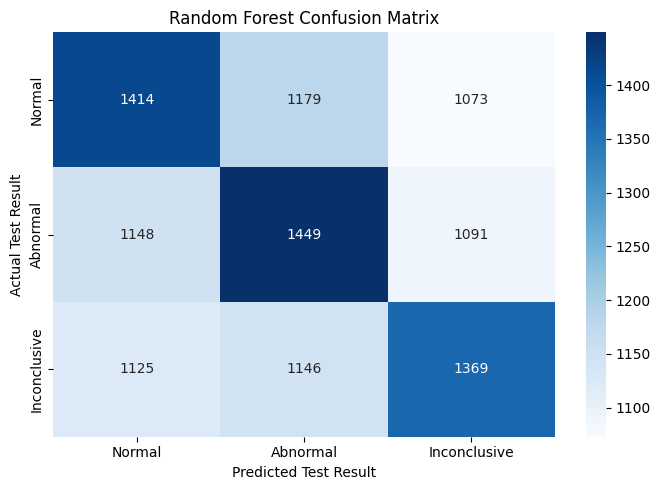

In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Normal", "Abnormal", "Inconclusive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Abnormal", "Inconclusive"],
    yticklabels=["Normal", "Abnormal", "Inconclusive"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Test Result")
plt.ylabel("Actual Test Result")

plt.tight_layout()
plt.show()

In [69]:
new_patient = pd.DataFrame({
    "Age": [45],
    "Gender": ["Female"],
    "Blood Type": ["A+"],
    "Medical Condition": ["Diabetes"],
    "Insurance Provider": ["Aetna"],
    "Admission Type": ["Urgent"],
    "Medication": ["Aspirin"]
})

prediction = rf_model.predict(new_patient)

print("Predicted Test Result:", prediction[0])

Predicted Test Result: Inconclusive


In [70]:
prediction_probabilities = rf_model.predict_proba(new_patient)

probability_df = pd.DataFrame(
    prediction_probabilities,
    columns=rf_model.named_steps["model"].classes_
) * 100

probability_df.round(2)

,Abnormal,Inconclusive,Normal
0,38.67,42.0,19.33


In [71]:
import joblib
joblib.dump(rf_model, 'rf_model_pipeline.pkl')

['rf_model_pipeline.pkl']